<a href="https://colab.research.google.com/github/AnthonyMath1022/AnthonyMath1022/blob/main/Copy_of_Retail_Analysis_ChebConvTCN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [45]:
import pandas as pd
import numpy as np
from IPython.display import display
from google.colab import drive
drive.mount('/content/drive')

print('Loading data...')
train_path = '/content/drive/MyDrive/Reatilforecast/src/train.csv'
train_df = pd.read_csv(train_path, low_memory=True)
train_df['date'] = pd.to_datetime(train_df['date'])
pd.set_option('display.max_columns', 10)
display(train_df)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loading data...


/tmp/ipython-input-2959674660.py:9: DtypeWarning: Columns (5) have mixed types. Specify dtype option on import or set low_memory=False.
  train_df = pd.read_csv(train_path, low_memory=True)


,id,date,store_nbr,item_nbr,unit_sales,onpromotion
0,0,2013-01-01,25,103665,7.0,NaN
1,1,2013-01-01,25,105574,1.0,NaN
2,2,2013-01-01,25,105575,2.0,NaN
3,3,2013-01-01,25,108079,1.0,NaN
4,4,2013-01-01,25,108701,1.0,NaN
...,...,...,...,...,...,...
125497035,125497035,2017-08-15,54,2089339,4.0,False
125497036,125497036,2017-08-15,54,2106464,1.0,True
125497037,125497037,2017-08-15,54,2110456,192.0,False
125497038,125497038,2017-08-15,54,2113914,198.0,True


In [46]:
start_date = '2017-07-01'
end_date = '2017-12-31'

train_df = train_df[(train_df['date'] >= start_date) & (train_df['date'] <= end_date)]
pd.set_option('display.max_columns', 10)
display(train_df)
train_df.count()
train_df.isna().sum()


,id,date,store_nbr,item_nbr,unit_sales,onpromotion
120642911,120642911,2017-07-01,1,99197,2.0,False
120642912,120642912,2017-07-01,1,103520,2.0,False
120642913,120642913,2017-07-01,1,103665,11.0,False
120642914,120642914,2017-07-01,1,105574,2.0,False
120642915,120642915,2017-07-01,1,105575,3.0,False
...,...,...,...,...,...,...
125497035,125497035,2017-08-15,54,2089339,4.0,False
125497036,125497036,2017-08-15,54,2106464,1.0,True
125497037,125497037,2017-08-15,54,2110456,192.0,False
125497038,125497038,2017-08-15,54,2113914,198.0,True


,0
id,0
date,0
store_nbr,0
item_nbr,0
unit_sales,0
onpromotion,0


In [47]:
import pandas as pd

item_path = '/content/drive/MyDrive/Reatilforecast/src/items.csv'
store_path = '/content/drive/MyDrive/Reatilforecast/src/stores.csv'
oil_path = '/content/drive/MyDrive/Reatilforecast/src/oil.csv'

item = pd.read_csv(item_path)
store = pd.read_csv(store_path)
oil = pd.read_csv(oil_path )
oil = oil[(oil['date'] >= start_date) & (oil['date'] <= end_date)]

train_df = pd.merge(train_df,item,on='item_nbr',how='left')
train_df = pd.merge(train_df,store,on='store_nbr',how='left')
train_df.isna().sum()

,0
id,0
date,0
store_nbr,0
item_nbr,0
unit_sales,0
onpromotion,0
family,0
class,0
perishable,0
city,0


In [48]:
import numpy as np

def most_frequent_sales(data, variable, N, all='TRUE'):


    # counts
    values, counts = np.unique(data[variable].to_numpy(), return_counts=True)

    # Ensure values and counts are 2D column vectors before stacking
    values_2d = values.reshape(-1, 1)
    counts_2d = counts.reshape(-1, 1)

    # Nx2 table: [value, count]
    labels_freq_pd = np.column_stack((values_2d, counts_2d))

    # sort by count desc
    labels_freq_pd = labels_freq_pd[np.argsort(labels_freq_pd[:, 1])[::-1]]

    # keep top N
    topN = labels_freq_pd[:N]
    main_labels = topN[:, 0] if all == 'False' else labels_freq_pd[:, 0]

    # raw labels (replace deprecated as_matrix)
    labels_raw_np = data[variable].to_numpy().reshape(-1, 1)

    # indices where label in main_labels (same style as your labels_filtered_index[0])
    labels_filtered_index = np.where(np.isin(labels_raw_np.ravel(), main_labels))

    return topN, labels_filtered_index

label_freq, labels_filtered_index = most_frequent_sales(train_df, 'item_nbr', 5, 'FALSE')
print("pd_train.shape=", labels_filtered_index[0].shape)

pd_train_filtered = train_df.loc[labels_filtered_index[0], :]
print("pd_train_filtered.shape = ", pd_train_filtered.shape)


pd_train.shape= (4854129,)
pd_train_filtered.shape =  (4854129, 13)


In [49]:
pd_train_filtered  = pd_train_filtered.drop(['city','state','type','cluster','store_nbr','item_nbr','family','class','id'], axis = 1)

In [50]:

dummy_variables = ['onpromotion','perishable']

for var in dummy_variables:
    dummy = pd.get_dummies(pd_train_filtered [var], prefix = var, drop_first = False).astype(int)
    pd_train_filtered  = pd.concat([pd_train_filtered ,dummy], axis = 1)

pd_train_filtered  = pd_train_filtered.drop(dummy_variables, axis = 1)


In [51]:
import pandas as pd

# 1. Ensure your date columns are actual datetime objects
pd_train_filtered ['date'] = pd.to_datetime(pd_train_filtered ['date'])
oil['date'] = pd.to_datetime(oil['date'])

# 2. Generate the complete date range automatically
# pd.date_range replaces the manual loop and delta calculation
calendar = pd.DataFrame({
    'date': pd.date_range(start=train_df.date.min(), end=train_df.date.max())
})

# 3. Merge
oil = calendar.merge(oil, on='date', how='left')

In [52]:
na_index_oil = oil[oil['dcoilwtico'].isnull() == True].index.values

#Define the index to use to apply the formala
na_index_oil_plus = na_index_oil.copy()
na_index_oil_minus = np.maximum(0, na_index_oil-1)

for i in range(len(na_index_oil)):
    k = 1
    while (na_index_oil[min(i+k,len(na_index_oil)-1)] == na_index_oil[i]+k):
        k += 1
    na_index_oil_plus[i] = min(len(oil)-1, na_index_oil_plus[i] + k )

#Apply the formula
for i in range(len(na_index_oil)):
    if (na_index_oil[i] == 0):
        oil.loc[na_index_oil[i], 'dcoilwtico'] = oil.loc[na_index_oil_plus[i], 'dcoilwtico']
    elif (na_index_oil[i] == len(oil)):
        oil.loc[na_index_oil[i], 'dcoilwtico'] = oil.loc[na_index_oil_minus[i], 'dcoilwtico']
    else:
        oil.loc[na_index_oil[i], 'dcoilwtico'] = (oil.loc[na_index_oil_plus[i], 'dcoilwtico'] + oil.loc[na_index_oil_minus[i], 'dcoilwtico'])/ 2

pd_train_filtered  = pd_train_filtered.merge(oil, left_on='date', right_on='date', how='left')


In [53]:
pd_train_filtered.sample(10)

,date,unit_sales,onpromotion_False,onpromotion_True,perishable_0,perishable_1,dcoilwtico
284602,2017-07-03,8.0,1,0,0,1,45.1100
298658,2017-07-03,1.0,1,0,1,0,45.1100
403509,2017-07-04,4.0,1,0,1,0,45.1100
2601239,2017-07-25,6.0,1,0,0,1,47.7700
2415567,2017-07-23,7.0,1,0,1,0,46.1025
1572199,2017-07-15,14.0,1,0,1,0,46.2750
3387643,2017-08-01,3.0,1,0,1,0,49.1900
999962,2017-07-10,1.0,1,0,1,0,44.4000
597761,2017-07-06,1.0,0,1,0,1,45.5200
3109011,2017-07-30,12.0,1,0,1,0,50.0875


In [54]:
pd_train_filtered.count()

,0
date,4854129
unit_sales,4854129
onpromotion_False,4854129
onpromotion_True,4854129
perishable_0,4854129
perishable_1,4854129
dcoilwtico,4854129


In [55]:

!pip install torch
!pip install torch_geometric
!pip install torch_geometric_temporal


In [56]:
import numpy as np
import pandas as pd
import torch
import torch_geometric
from sklearn.preprocessing import MinMaxScaler

# --- CONFIGURATION ---
LOOKBACK = 7
HORIZON = 1
TOP_N = 10

# 1. Filter for Top 10 Items
# We use a wider date range (from Jan 2017) to ensure enough data for lookback and splitting.
local_start_date = '2017-01-01'

temp_base_df = pd.read_csv(train_path, low_memory=True)
temp_base_df['date'] = pd.to_datetime(temp_base_df['date'])
temp_base_df = temp_base_df[(temp_base_df['date'] >= local_start_date) & (temp_base_df['date'] <= end_date)].copy()

# Re-merge with item and store data
temp_item_df = pd.read_csv(item_path)
temp_store_df = pd.read_csv(store_path)
temp_base_df = pd.merge(temp_base_df, temp_item_df, on='item_nbr', how='left')
temp_base_df = pd.merge(temp_base_df, temp_store_df, on='store_nbr', how='left')

# Reload and merge Oil data (full range to cover Jan-July)
oil_full = pd.read_csv(oil_path)
oil_full['date'] = pd.to_datetime(oil_full['date'])
temp_base_df = pd.merge(temp_base_df, oil_full[['date', 'dcoilwtico']], on='date', how='left')

# Top 10 items
top_items = temp_base_df['item_nbr'].value_counts().head(TOP_N).index
pd_train_filtered = temp_base_df[temp_base_df['item_nbr'].isin(top_items)].copy()

# 2. Pivot the Data to Wide Format
# Sales Pivot
pivoted_sales = pd_train_filtered.pivot_table(
    index='date',
    columns='item_nbr',
    values='unit_sales',
    fill_value=0
)
pivoted_sales.columns = [f'sales_{i}' for i in pivoted_sales.columns]

# Promotion Pivot
if 'onpromotion' in pd_train_filtered.columns:
    pd_train_filtered['onpromotion'] = pd_train_filtered['onpromotion'].astype(int)
    pivoted_promo = pd_train_filtered.pivot_table(
        index='date',
        columns='item_nbr',
        values='onpromotion',
        fill_value=0
    )
    pivoted_promo.columns = [f'promo_{i}' for i in pivoted_promo.columns]
else:
    pivoted_promo = pd.DataFrame()

# Oil Data (Common Feature)
oil_series = pd_train_filtered.groupby('date')['dcoilwtico'].max()

# 3. Combine into one Wide Dataframe
combined = pd.concat([pivoted_sales, pivoted_promo, oil_series], axis=1)

# Fill gaps
combined = combined.ffill().bfill()

# Define targets and features
stock_cols = pivoted_sales.columns.tolist()
print(f"Target Columns ({len(stock_cols)}): {stock_cols}")
print(f"Total Features: {combined.shape[1]}")
print(f"Total Data Points (Days): {len(combined)}")



/tmp/ipython-input-913725317.py:16: DtypeWarning: Columns (5) have mixed types. Specify dtype option on import or set low_memory=False.
  temp_base_df = pd.read_csv(train_path, low_memory=True)


Target Columns (10): ['sales_222879', 'sales_261052', 'sales_265559', 'sales_314384', 'sales_323013', 'sales_364606', 'sales_502331', 'sales_1052563', 'sales_1157564', 'sales_1162382']
Total Features: 21
Total Data Points (Days): 227


In [57]:
corr = combined[stock_cols].corr(method='spearman')
corr = (corr - (corr==1))
corr = corr.abs()
corr.head(10)
corr_matrix = corr

In [58]:
from sklearn.feature_selection import mutual_info_regression

def mutual_info_matrix(data):
    n = data.shape[1]
    mi_matrix = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            if i != j:
                mi = mutual_info_regression(
                    data[:, [i]], data[:, j]
                )[0]
                mi_matrix[i, j] = mi
    return mi_matrix

mi_matrix = mutual_info_matrix(combined[stock_cols].values).round(4)

In [59]:
def create_combine_edge(corr_matrix, mi_matrix, corr_threshold=0.3, mi_threshold=0.1):
    edge_indices = []
    edge_weights = []

    for i in range(len(corr_matrix)):
        for j in range(len(corr_matrix)):
            if i !=j:
                corr_val = abs(corr_matrix.iloc[i, j])
                mi_val = abs(mi_matrix[i, j])
                if corr_val > corr_threshold and mi_val > mi_threshold:
                    edge_indices.append((i, j))
                    edge_weights.append((corr_val, mi_val))
    return edge_indices, edge_weights

edge_indices, edge_weights = create_combine_edge(corr_matrix, mi_matrix, corr_threshold=0.3, mi_threshold=0.1)
node_features = torch.tensor(combined[stock_cols].values.T, dtype=torch.float)

In [60]:
from torch_geometric.data import Data
edge_indices, edge_weights = create_combine_edge(corr_matrix, mi_matrix, corr_threshold=0.3, mi_threshold=0.1)
node_features = torch.tensor(combined[stock_cols].values.T, dtype=torch.float)
edge_index_t = torch.tensor(edge_indices, dtype=torch.long).t().contiguous()
edge_index = torch.cat([edge_index_t, edge_index_t[[1, 0], :]], dim=1)
edge_attr = torch.tensor(edge_weights, dtype=torch.float)
edge_attr = torch.cat([edge_attr, edge_attr], dim=0)

target = torch.tensor(combined[stock_cols].values.T, dtype=torch.float)
stock_graph_data = Data(x=node_features, edge_index=edge_index, edge_attr=edge_attr, y=target)

class StockData(Data):
    def __init__(self, x=None, edge_index=None, edge_attr=None, y=None):
        super(StockData, self).__init__(x=x, edge_index=edge_index, edge_attr=edge_attr, y=y)

custom_stock_data = StockData(x=node_features, edge_index=edge_index, edge_attr=edge_attr, y=target)
print(custom_stock_data)

StockData(x=[10, 227], edge_index=[2, 164], edge_attr=[164, 2], y=[10, 227])


In [61]:
from sklearn.preprocessing import MinMaxScaler

# Initialize the scaler
scaler = MinMaxScaler()

# Scale the stock price data
scaled_data = scaler.fit_transform(combined[stock_cols])

# Create a new data object for the normalized data
normalized_data = stock_graph_data.clone()

# Update the node features and targets with the scaled data
# The data needs to be transposed to match the shape [num_nodes, num_timesteps]
normalized_data.x = torch.tensor(scaled_data.T, dtype=torch.float)
normalized_data.y = torch.tensor(scaled_data.T, dtype=torch.float)

print("\\n--- Normalized Data Object ---")
print(normalized_data)
print("\\nNormalized node features (first 5 values of first node):")
print(normalized_data.x[0, :5])

print(f"\\nMin of normalized features for the first node: {torch.min(normalized_data.x[0])}")
print(f"Max of normalized features for the first node: {torch.max(normalized_data.x[0])}")

\n--- Normalized Data Object ---
Data(x=[10, 227], edge_index=[2, 164], edge_attr=[164, 2], y=[10, 227])
\nNormalized node features (first 5 values of first node):
tensor([0.0113, 0.9161, 0.5865, 0.3979, 0.2932])
\nMin of normalized features for the first node: 0.0
Max of normalized features for the first node: 1.0


In [62]:
from torch_geometric_temporal.signal import StaticGraphTemporalSignal
from torch_geometric_temporal import temporal_signal_split

def make_graph_windows(signal, n_in: int, n_out: int, multi_step: bool = True):
    """
    Rolling window creation for temporal GNN forecasting.

    Args:
        signal: StaticGraphTemporalSignal with T timesteps
        n_in: input sequence length
        n_out: forecast horizon
        multi_step: if True, return [n_out, N, F]; else [N, F]
    """
    feats = [np.asarray(f, dtype=np.float32) for f in signal.features]
    T = len(feats)
    windows = []

    # Calculate valid starting positions
    num_windows = T - n_in - n_out + 1

    if num_windows <= 0:
        raise ValueError(f"Not enough timesteps: T={T}, need at least {n_in + n_out}")

    for i in range(num_windows):
        # Input: timesteps [i, i+n_in)
        X = np.stack(feats[i : i + n_in], axis=0)  # [n_in, N, F]

        # Output: timesteps [i+n_in, i+n_in+n_out)
        if multi_step:
            Y = np.stack(feats[i + n_in : i + n_in + n_out], axis=0)  # [n_out, N, F]
        else:
            Y = feats[i + n_in]  # [N, F]

        windows.append((X, Y))

    return {
        "edge_index": torch.tensor(signal.edge_index, dtype=torch.long),
        "edge_weight": torch.tensor(signal.edge_weight, dtype=torch.float),

        "windows": windows,
    }



# Build temporal_dataset from existing scaled_data and graph (edge_index/edge_attr)
# Each timestep feature is a single scalar per node (scaled close), and target is next-step value.
T = scaled_data.shape[0]
X_list = [scaled_data[t].reshape(-1, 1).astype(np.float32) for t in range(T - 1)]       # [N, 1]
Y_list = [scaled_data[t + 1].reshape(-1, 1).astype(np.float32) for t in range(T - 1)]   # [N, 1]

edge_index_np = edge_index.detach().cpu().numpy() if isinstance(edge_index, torch.Tensor) else np.asarray(edge_index)
# Use the first column of edge_attr (correlation) as edge weights
edge_weight_np = (edge_attr[:, 0].detach().cpu().numpy()
                  if isinstance(edge_attr, torch.Tensor)
                  else np.asarray(edge_attr)[:, 0])


temporal_dataset = StaticGraphTemporalSignal(
    edge_index=edge_index_np,
    edge_weight=edge_weight_np.astype(np.float32),
    features=X_list,
    targets=Y_list,
)


train_signal, test_signal = temporal_signal_split(temporal_dataset, train_ratio=0.8678414097) # for 2018-01-01 split 0.6843, 2012-01-01 split 0.83
total_timesteps = len(temporal_dataset.features)
split_idx = int(total_timesteps*0.15)
train_signal = train_signal[:-split_idx+1]
val_signal  = train_signal[-split_idx:]
test_signal = test_signal


print(f'train_signal: {len(train_signal.features)}, val_signal: {len(val_signal.features)}, test_signal: {len(test_signal.features)}')

n_in, n_out = 7,1

train_windows = make_graph_windows(train_signal, n_in, n_out, multi_step=True)
val_windows  = make_graph_windows(train_signal[:split_idx],  n_in, n_out, multi_step=True)
test_windows  = make_graph_windows(test_signal,  n_in, n_out, multi_step=True)
print(f"# train windows: {len(train_windows['windows'])},# val windows: {len(val_windows['windows'])}, # test windows: {len(test_windows['windows'])}")


train_signal: 164, val_signal: 33, test_signal: 30
# train windows: 157,# val windows: 26, # test windows: 23


In [63]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from typing import Optional
from torch_geometric.typing import Adj, OptTensor
from torch_geometric.nn import ChebConv
import random
import os

class MultiHeadTemporalAttention(nn.Module):
    """
    Multi-head temporal attention with optional causal masking.
    Processes temporal sequences with multiple attention heads.
    """
    def __init__(
        self,
        in_channels: int,
        out_channels: int,
        num_heads: int = 8,
        dropout: float = 0.1,
        causal_mask: bool = False
    ):
        super(MultiHeadTemporalAttention, self).__init__()

        assert out_channels % num_heads == 0, \
            f"out_channels ({out_channels}) must be divisible by num_heads ({num_heads})"

        self.in_channels = in_channels
        self.out_channels = out_channels
        self.num_heads = num_heads
        self.head_dim = out_channels // num_heads
        self.causal_mask = causal_mask

        self.query_proj = nn.Linear(in_channels, out_channels)
        self.key_proj = nn.Linear(in_channels, out_channels)
        self.value_proj = nn.Linear(in_channels, out_channels)
        self.out_proj = nn.Linear(out_channels, out_channels)

        self.dropout = nn.Dropout(dropout)
        self.scale = self.head_dim ** -0.5

    def create_causal_mask(self, seq_len: int, device: torch.device) -> torch.Tensor:
        """Create causal mask to prevent attending to future positions."""
        mask = torch.triu(torch.ones(seq_len, seq_len, device=device), diagonal=1)
        return mask.bool()

    def forward(
        self,
        x: torch.Tensor,
        attn_mask: Optional[torch.Tensor] = None,
        key_padding_mask: Optional[torch.Tensor] = None
    ) -> torch.Tensor:
        """
        Args:
            x: [B, T, N, F_in] - Batch, Time, Nodes, Features
            attn_mask: [T, T] - Attention mask (True = masked)
            key_padding_mask: [B, T] - Padding mask (True = masked)

        Returns:
            out: [B, T, N, F_out]
        """
        B, T, N, F_in = x.shape

        # Reshape: [B, T, N, F] -> [B*N, T, F]
        x_reshaped = x.permute(0, 2, 1, 3).contiguous().view(B * N, T, F_in)

        # Project to Q, K, V
        Q = self.query_proj(x_reshaped)  # [B*N, T, out_channels]
        K = self.key_proj(x_reshaped)
        V = self.value_proj(x_reshaped)

        # Reshape for multi-head: [B*N, T, num_heads, head_dim] -> [B*N, num_heads, T, head_dim]
        Q = Q.view(B * N, T, self.num_heads, self.head_dim).transpose(1, 2)
        K = K.view(B * N, T, self.num_heads, self.head_dim).transpose(1, 2)
        V = V.view(B * N, T, self.num_heads, self.head_dim).transpose(1, 2)

        # Attention scores: [B*N, num_heads, T, T]
        attn_scores = torch.matmul(Q, K.transpose(-2, -1)) * self.scale

        # Apply causal mask
        if self.causal_mask:
            causal_mask = self.create_causal_mask(T, x.device)
            attn_scores = attn_scores.masked_fill(causal_mask.unsqueeze(0).unsqueeze(0), float('-inf'))

        # Apply custom attention mask
        if attn_mask is not None:
            attn_scores = attn_scores.masked_fill(attn_mask.unsqueeze(0).unsqueeze(0), float('-inf'))

        # Apply key padding mask
        if key_padding_mask is not None:
            key_padding_mask = key_padding_mask.repeat_interleave(N, dim=0)
            key_padding_mask = key_padding_mask.unsqueeze(1).unsqueeze(2)
            attn_scores = attn_scores.masked_fill(key_padding_mask, float('-inf'))

        # Softmax and dropout
        attn_weights = F.softmax(attn_scores, dim=-1)
        attn_weights = self.dropout(attn_weights)

        # Apply attention to values
        attn_out = torch.matmul(attn_weights, V)  # [B*N, num_heads, T, head_dim]
        attn_out = attn_out.transpose(1, 2).contiguous().view(B * N, T, self.out_channels)

        # Output projection
        out = self.out_proj(attn_out)  # [B*N, T, out_channels]

        # Reshape back: [B*N, T, F] -> [B, T, N, F]
        out = out.view(B, N, T, self.out_channels).permute(0, 2, 1, 3)

        return out


class TemporalConvNet(nn.Module):
    """Temporal Convolutional Network with causal convolutions."""
    def __init__(
        self,
        in_channels: int,
        hidden_channels: list,
        kernel_size: int = 10,
        dropout: float = 0.2
    ):
        super().__init__()

        layers = []
        num_levels = len(hidden_channels)

        for i in range(num_levels):
            in_ch = in_channels if i == 0 else hidden_channels[i - 1]
            out_ch = hidden_channels[i]
            dilation = 2 ** i
            # Causal padding: only pad on the left side
            padding = (kernel_size - 1) * dilation

            layers.append(
                nn.Conv1d(
                    in_ch, out_ch, kernel_size,
                    padding=padding,
                    dilation=dilation
                )
            )
            layers.append(nn.Tanh())
            layers.append(nn.Dropout(dropout))

        self.network = nn.Sequential(*layers)
        self.kernel_size = kernel_size

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Args:
            x: [B, C, T] input tensor

        Returns:
            out: [B, C, T] output with same temporal length (causal)
        """
        out = self.network(x)
        # Crop to maintain causality and original length
        return out[:, :, :x.size(2)]


class ChebConvTCN(nn.Module):
    """
    Chebyshev Convolutional Temporal Graph Network with Multi-Head Attention.

    Flow: ChebConv -> Multi-Head Temporal Attention -> TCN -> Output
    """
    def __init__(
        self,
        in_channels: int,
        g_hidden: int,
        spatial_channels: int,
        temporal_channels: list,
        forecast_horizon: int = 5,
        K: int = 5,
        kernel_size: int = 8,
        dropout: float = 0.2,
        use_temporal_attention: bool = True,
        num_heads: int = 8,
        attn_dropout: float = 0.1,
        attn_residual: bool = True,
        use_layernorm_after_attn: bool = True,
        causal_mask: bool = False,
    ):
        super().__init__()

        self.in_channels = in_channels
        self.spatial_channels = spatial_channels
        self.use_temporal_attention = use_temporal_attention
        self.attn_residual = attn_residual
        self.forecast_horizon = forecast_horizon

        # Spatial graph convolution (ChebConv)
        self.gconv = ChebConv(in_channels, g_hidden, K)

        # Projection layer to match dimensions
        self.spatial_proj = nn.Linear(g_hidden, spatial_channels)

        # Residual connection for input
        self.residual = nn.Linear(in_channels, g_hidden) if in_channels != g_hidden else nn.Identity()

        # Multi-head temporal attention
        if use_temporal_attention:
            self.temporal_attn = MultiHeadTemporalAttention(
                in_channels=spatial_channels,
                out_channels=spatial_channels,
                num_heads=num_heads,
                dropout=attn_dropout,
                causal_mask=causal_mask
            )
        else:
            self.temporal_attn = None

        # Layer normalization after attention
        self.norm_after_attn = (
            nn.LayerNorm(spatial_channels)
            if (use_temporal_attention and use_layernorm_after_attn)
            else None
        )

        # Temporal convolutional network
        self.temporal_conv = TemporalConvNet(
            in_channels=spatial_channels,
            hidden_channels=temporal_channels,
            kernel_size=kernel_size,
            dropout=dropout
        )

        # Output projection
        self.output_layer = nn.Linear(temporal_channels[-1], forecast_horizon)

    def forward(
        self,
        x: torch.Tensor,
        edge_index: Adj,
        edge_weight: OptTensor = None,
        attn_mask: Optional[torch.Tensor] = None,
        key_padding_mask: Optional[torch.Tensor] = None
    ) -> torch.Tensor:
        """
        Args:
            x: [B, N, T, F_in] or [N, T, F_in]
            edge_index: [2, E]
            edge_weight: [E] optional edge weights
            attn_mask: [T, T] - Optional attention mask
            key_padding_mask: [B, T] - Optional padding mask

        Returns:
            out: [B, N, forecast_horizon] or [N, forecast_horizon]
        """
        batch_mode = x.dim() == 4
        if not batch_mode:
            x = x.unsqueeze(0)

        B, N, T, F = x.shape

        # 1) Spatial convolution per time-step using ChebConv
        # Reshape to process all batch-time combinations at once
        x_flat = x.permute(0, 2, 1, 3).reshape(B * T, N, F)  # [B*T, N, F]

        spatial_flat = []
        for i in range(B * T):
            # Apply ChebConv
            gconv_out = self.gconv(x_flat[i], edge_index, edge_weight)  # [N, g_hidden]

            # Optional residual connection
            res = self.residual(x_flat[i])  # [N, g_hidden]
            gconv_out = gconv_out + res

            # Project to spatial_channels
            spatial_out = self.spatial_proj(gconv_out)  # [N, spatial_channels]
            spatial_flat.append(spatial_out)

        spatial_flat = torch.stack(spatial_flat, dim=0)  # [B*T, N, spatial_channels]
        spatial_features = spatial_flat.view(B, T, N, self.spatial_channels).permute(0, 2, 1, 3)
        # [B, N, T, spatial_channels]

        # 2) Multi-head temporal attention with masking
        if self.temporal_attn is not None:
            attn_input = spatial_features.permute(0, 2, 1, 3)  # [B, T, N, spatial_channels]

            attn_output = self.temporal_attn(
                attn_input,
                attn_mask=attn_mask,
                key_padding_mask=key_padding_mask
            )  # [B, T, N, spatial_channels]

            attn_output = attn_output.permute(0, 2, 1, 3).contiguous()  # [B, N, T, spatial_channels]

            # Residual connection
            if self.attn_residual:
                spatial_features = spatial_features + attn_output
            else:
                spatial_features = attn_output

            # Layer normalization
            if self.norm_after_attn is not None:
                spatial_features = self.norm_after_attn(spatial_features)

        # 3) Temporal convolution
        # Reshape: [B, N, T, C] -> [B*N, C, T]
        C = spatial_features.size(-1)
        tcn_input = spatial_features.permute(0, 1, 3, 2).reshape(B * N, C, T)
        tcn_output = self.temporal_conv(tcn_input)  # [B*N, temporal_channels[-1], T]

        # 4) Take last timestep and project to forecast horizon
        tcn_last = tcn_output[:, :, -1]  # [B*N, temporal_channels[-1]]
        out = self.output_layer(tcn_last)  # [B*N, forecast_horizon]
        out = out.view(B, N, self.forecast_horizon)  # [B, N, forecast_horizon]

        if not batch_mode:
            out = out.squeeze(0)

        return out
'''
def seed_everything(seed: int = 42):
    """Sets the seed for generating random numbers to allow for reproducible results."""

    # 1. Set seed for Python's built-in random number generator
    random.seed(seed)

    # 2. Set seed for environment variables (some hash-based operations usage)
    os.environ['PYTHONHASHSEED'] = str(seed)

    # 3. Set seed for NumPy (used for data manipulation)
    np.random.seed(seed)

    # 4. Set seed for PyTorch (CPU)
    torch.manual_seed(seed)

    # 5. Set seed for PyTorch (GPU)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed) # For multi-GPU

        # 6. Force deterministic algorithms (Important for reproducibility!)
        # Note: This might slow down training slightly
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

    print(f"Random seed set to: {seed}")

# --- Usage ---
seed_everything(42)
'''

model = ChebConvTCN(
        in_channels=1,
        g_hidden=128,
        spatial_channels=128,
        temporal_channels=[128, 64],
        forecast_horizon=n_out,
        K=1,
        kernel_size=8,
        dropout=0.2,
        use_temporal_attention=True,
        num_heads=8,
        attn_dropout=0.2,
        attn_residual=True,
        use_layernorm_after_attn=True,
        causal_mask=True
    )
print(model)

ChebConvTCN(
  (gconv): ChebConv(1, 128, K=1, normalization=sym)
  (spatial_proj): Linear(in_features=128, out_features=128, bias=True)
  (residual): Linear(in_features=1, out_features=128, bias=True)
  (temporal_attn): MultiHeadTemporalAttention(
    (query_proj): Linear(in_features=128, out_features=128, bias=True)
    (key_proj): Linear(in_features=128, out_features=128, bias=True)
    (value_proj): Linear(in_features=128, out_features=128, bias=True)
    (out_proj): Linear(in_features=128, out_features=128, bias=True)
    (dropout): Dropout(p=0.2, inplace=False)
  )
  (norm_after_attn): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
  (temporal_conv): TemporalConvNet(
    (network): Sequential(
      (0): Conv1d(128, 128, kernel_size=(8,), stride=(1,), padding=(7,))
      (1): Tanh()
      (2): Dropout(p=0.2, inplace=False)
      (3): Conv1d(128, 64, kernel_size=(8,), stride=(1,), padding=(14,), dilation=(2,))
      (4): Tanh()
      (5): Dropout(p=0.2, inplace=False)
    )


In [64]:
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)
criterion = torch.nn.MSELoss()

def train(model, train_data, optimizer, criterion):
    model.train()
    total_loss = 0

    # Access the windows list from the dictionary
    windows = train_data['windows']
    edge_index = train_data['edge_index']
    edge_weight = train_data['edge_weight']

    for X, Y in windows:
        optimizer.zero_grad()
        # X shape: [n_in, N, F], Y shape: [n_out, N, F]
        # We need the last timestep of X as input: [1, N, 1, F]
        x = torch.tensor(X[-1:], dtype=torch.float)  # [1, N, F]
        y = torch.tensor(Y, dtype=torch.float)  # [n_out, N, F]

        # Reshape x to [1, N, 1, F] - [B, N, T, F]
        x = x.permute(1, 0, 2).unsqueeze(0)  # [1, N, 1, F]

        out = model(x, edge_index)  # [1, N, forecast_horizon]

        # Reshape y to match output: [1, N, n_out]
        y = y.permute(1, 0, 2).squeeze(-1)  # [N, n_out]

        loss = criterion(out.squeeze(0), y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(windows)


def val(model, val_data, criterion, device="cpu"):
    model.eval()
    total_loss, steps = 0.0, 0

    windows = val_data['windows']
    edge_index = val_data['edge_index']

    with torch.no_grad():
        for X, Y in windows:
            x = torch.tensor(X[-1:], dtype=torch.float)
            y = torch.tensor(Y, dtype=torch.float)

            x = x.permute(1, 0, 2).unsqueeze(0)  # [1, N, 1, F]

            out = model(x, edge_index)

            y = y.permute(1, 0, 2).squeeze(-1)  # [N, n_out]

            loss = criterion(out.squeeze(0), y)
            total_loss += loss.item()
            steps += 1

    return total_loss / steps


def test(model, test_data, criterion, device="cpu"):
    model.eval()
    total_loss, steps = 0.0, 0
    all_predictions = []
    all_targets = []

    windows = test_data['windows']
    edge_index = test_data['edge_index']

    with torch.no_grad():
        for X, Y in windows:
            x = torch.tensor(X[-1:], dtype=torch.float)
            y = torch.tensor(Y, dtype=torch.float)

            x = x.permute(1, 0, 2).unsqueeze(0)  # [1, N, 1, F]

            out = model(x, edge_index)

            y = y.permute(1, 0, 2).squeeze(-1)  # [N, n_out]

            loss = criterion(out.squeeze(0), y)
            total_loss += loss.item()
            steps += 1

            all_predictions.append(out.squeeze(0).cpu().numpy())
            all_targets.append(y.cpu().numpy())

    avg_loss = total_loss / steps
    predictions = np.stack(all_predictions, axis=0)
    targets = np.stack(all_targets, axis=0)

    return avg_loss, predictions, targets

epochs = 2000
best_test_loss = float('inf')

for epoch in range(epochs):
    train_loss = train(model, train_windows, optimizer, criterion)

    if epoch % 5 == 0:
        total_loss = val(model, val_windows, criterion)

        print(f"Epoch {epoch+1}/{epochs}")
        print(f"  Train Loss: {train_loss:.6f}")
        print(f"  Val Loss:  {total_loss:.6f}")

        if total_loss < best_test_loss:
            best_test_loss = total_loss
            torch.save(model.state_dict(), 'best_model.pth')
            print(f"  ✓ Saved best model (val loss: {total_loss:.6f})")

print("\n" + "="*50)
print("Final Evaluation")
print("="*50)
test_loss, test_preds, test_targets = test(model, test_windows, criterion)
print(f"Final Test Loss: {test_loss:.6f}")

# Note: predictions now have shape [num_windows, N, n_out]
# For inverse transform, you may need to reshape appropriately
print(f"\nPrediction shape: {test_preds.shape}")
print(f"Target shape: {test_targets.shape}")

Epoch 1/2000
  Train Loss: 0.037446
  Val Loss:  0.019566
  ✓ Saved best model (val loss: 0.019566)
Epoch 6/2000
  Train Loss: 0.024085
  Val Loss:  0.019441
  ✓ Saved best model (val loss: 0.019441)
Epoch 11/2000
  Train Loss: 0.024121
  Val Loss:  0.019591
Epoch 16/2000
  Train Loss: 0.023694
  Val Loss:  0.019279
  ✓ Saved best model (val loss: 0.019279)
Epoch 21/2000
  Train Loss: 0.023360
  Val Loss:  0.019533
Epoch 26/2000
  Train Loss: 0.023701
  Val Loss:  0.019189
  ✓ Saved best model (val loss: 0.019189)
Epoch 31/2000
  Train Loss: 0.023440
  Val Loss:  0.018685
  ✓ Saved best model (val loss: 0.018685)
Epoch 36/2000
  Train Loss: 0.023233
  Val Loss:  0.019204
Epoch 41/2000
  Train Loss: 0.022563
  Val Loss:  0.018635
  ✓ Saved best model (val loss: 0.018635)
Epoch 46/2000
  Train Loss: 0.023125
  Val Loss:  0.018560
  ✓ Saved best model (val loss: 0.018560)
Epoch 51/2000
  Train Loss: 0.023046
  Val Loss:  0.018575
Epoch 56/2000
  Train Loss: 0.023280
  Val Loss:  0.018836


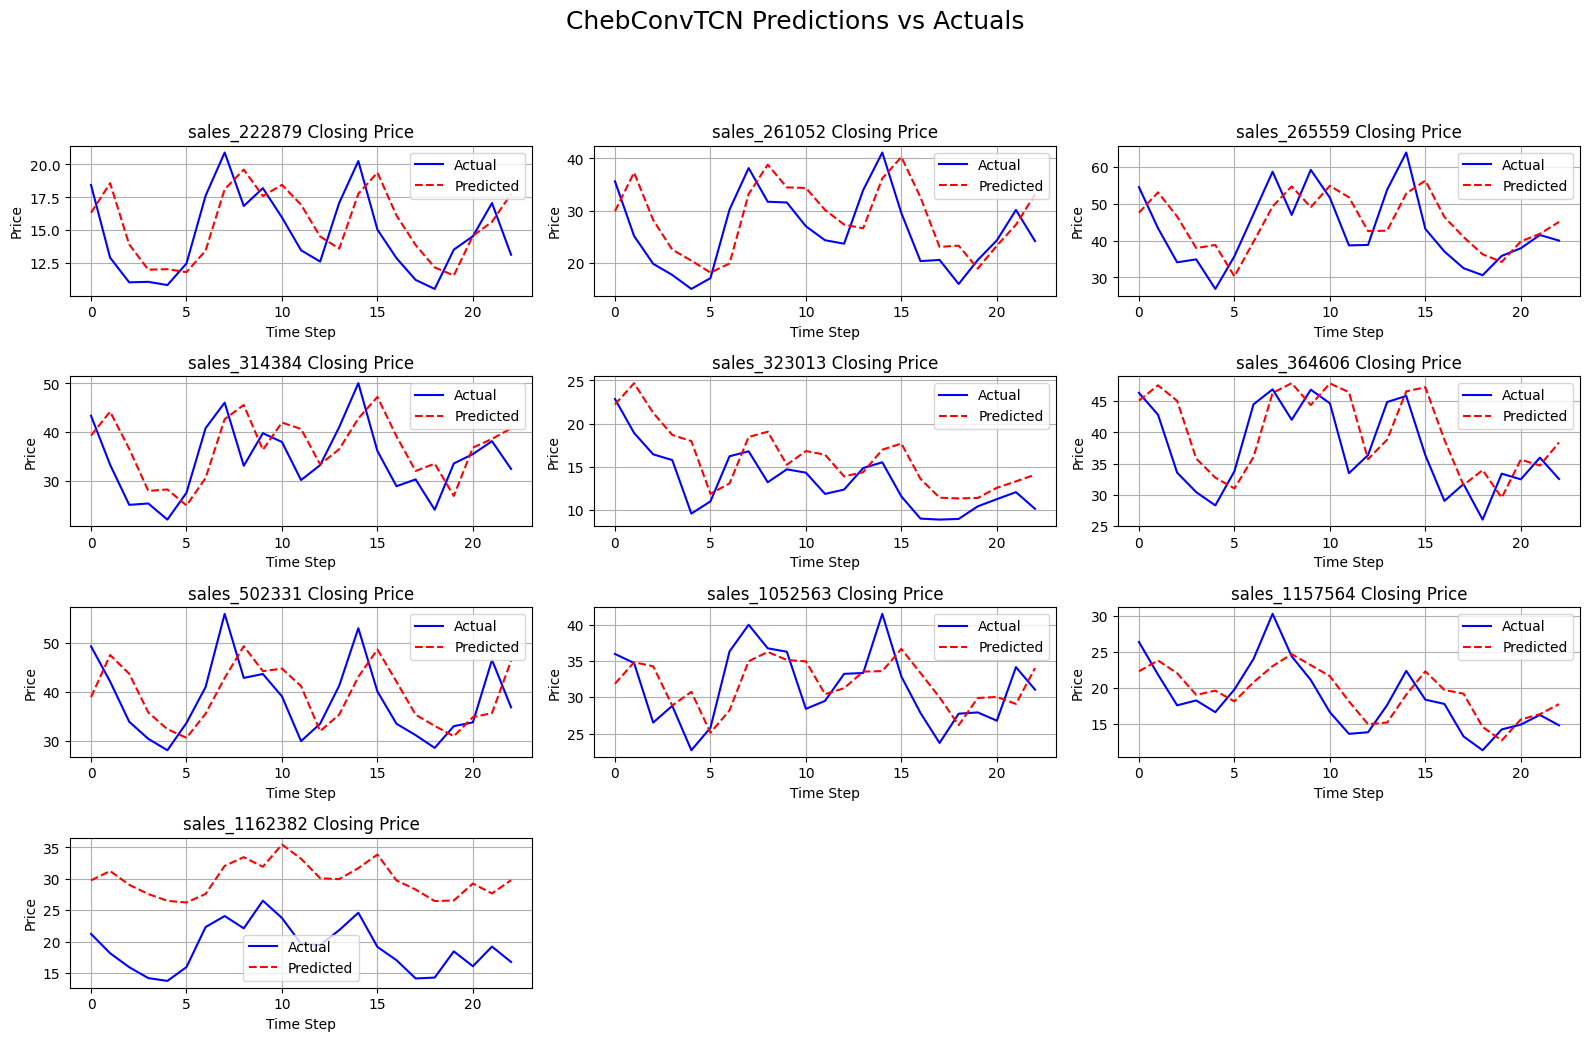


Metrics for sales_222879:
MSE: 8.117415428161621
MAE: 2.497114658355713
RMSE: 2.849107830209594
MAPE: 17.499181747436523
MSPE: 8.117415428161621
sqrt MSPE: 2.8491077423095703
R2: 0.12409138679504395

Metrics for sales_261052:
MSE: 47.00481033325195
MAE: 6.025102138519287
RMSE: 6.856005421034318
MAPE: 24.536344528198242
MSPE: 47.00481033325195
sqrt MSPE: 6.8560051918029785
R2: 0.05856353044509888

Metrics for sales_265559:
MSE: 70.58238220214844
MAE: 7.482372760772705
RMSE: 8.401332168302146
MAPE: 18.109968185424805
MSPE: 70.58238220214844
sqrt MSPE: 8.401331901550293
R2: 0.25569820404052734

Metrics for sales_314384:
MSE: 53.53791046142578
MAE: 6.203423976898193
RMSE: 7.316960466028622
MAPE: 19.35685157775879
MSPE: 53.53791046142578
sqrt MSPE: 7.316960334777832
R2: -0.07223236560821533

Metrics for sales_323013:
MSE: 13.368090629577637
MAE: 2.973212480545044
RMSE: 3.656239957877168
MAPE: 24.647907257080078
MSPE: 13.368090629577637
sqrt MSPE: 3.6562399864196777
R2: -0.10883140563964844

In [65]:
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

test_preds_original = np.zeros_like(test_preds)
test_targets_original = np.zeros_like(test_targets)

for i in range(n_out):
    # For each forecast step, inverse transform: [num_windows, N]
    test_preds_original[:, :, i] = scaler.inverse_transform(test_preds[:, :, i])
    test_targets_original[:, :, i] = scaler.inverse_transform(test_targets[:, :, i])

# For visualization, we can use the first forecast step or average across all steps
# Using the first forecast step (index 0):
inversed_actuals = test_targets_original[:, :, 0]
inversed_predictions = test_preds_original[:, :, 0]


plt.figure(figsize=(16, 12))
plt.suptitle('ChebConvTCN Predictions vs Actuals', fontsize=18, y=1.02)  # main title

for i, col in enumerate(stock_cols):
    plt.subplot(5, 3, i+1)
    plt.plot(inversed_actuals[:, i], label='Actual', color='blue')
    plt.plot(inversed_predictions[:, i], label='Predicted', color='red', linestyle='--')
    plt.title(f'{col} Closing Price')
    plt.xlabel('Time Step')
    plt.ylabel('Price')
    plt.legend()
    plt.grid(True)

plt.tight_layout(rect=[0, 0, 1, 0.97])  # leave room for suptitle
plt.show()


from sklearn import metrics
def mean_absolute_percentage_error(y_test, y_pred):
    y_true, y_pred = np.array(y_test), np.array(y_pred)
    return np.mean(np.abs((y_test - y_pred) / y_test)) * 100

def mean_squared_prediction_error(y_test, y_pred):
    y_true, y_pred = np.array(y_test), np.array(y_pred)
    return np.mean(((y_test - y_pred))**2)


for i, col in enumerate(stock_cols):
    print(f"\nMetrics for {col}:")
    print(f'MSE: {metrics.mean_squared_error(inversed_actuals[:, i], inversed_predictions[:, i])}')
    print(f'MAE: {metrics.mean_absolute_error(inversed_actuals[:, i], inversed_predictions[:, i])}')
    print(f'RMSE: {np.sqrt(metrics.mean_squared_error(inversed_actuals[:, i], inversed_predictions[:, i]))}')
    print(f'MAPE: {mean_absolute_percentage_error(inversed_actuals[:, i], inversed_predictions[:, i])}')
    print(f'MSPE: {mean_squared_prediction_error(inversed_actuals[:, i], inversed_predictions[:, i])}')
    print(f'sqrt MSPE: {np.sqrt(mean_squared_prediction_error(inversed_actuals[:, i], inversed_predictions[:, i]))}')
    print(f'R2: {r2_score(inversed_actuals[:, i], inversed_predictions[:, i])}')

# Overall metrics
print("\nOverall Metrics:")
print(f'MSE: {metrics.mean_squared_error(inversed_actuals, inversed_predictions)}')
print(f'MAE: {metrics.mean_absolute_error(inversed_actuals, inversed_predictions)}')
print(f'RMSE: {np.sqrt(metrics.mean_squared_error(inversed_actuals, inversed_predictions))}')
print(f'MAPE: {mean_absolute_percentage_error(inversed_actuals, inversed_predictions)}')
print(f'MSPE: {mean_squared_prediction_error(inversed_actuals, inversed_predictions)}')
print(f'sqrt MSPE: {np.sqrt(mean_squared_prediction_error(inversed_actuals, inversed_predictions))}')
print(f'R2: {r2_score(inversed_actuals, inversed_predictions)}')

In [66]:
train_loss, train_predictions, train_actuals = test(model, train_windows, criterion)


# Reshape to [total_timesteps, n_features] by flattening the window/horizon axes
train_predictions_reshaped = train_predictions.reshape(-1, len(stock_cols))
train_actuals_reshaped = train_actuals.reshape(-1, len(stock_cols))


# Inverse transform using the scaler fitted earlier
inversed_train_predictions = scaler.inverse_transform(train_predictions_reshaped)
inversed_train_actuals = scaler.inverse_transform(train_actuals_reshaped)
print(f"Train Loss: {train_loss:.4f}")
print(f"MSE is : {metrics.mean_squared_error(inversed_train_actuals, inversed_train_predictions)}")
print(f"RMSE is : {np.sqrt(metrics.mean_squared_error(inversed_train_actuals, inversed_train_predictions))}")

for i, col in enumerate(stock_cols):
    print(f"\nMetrics for {col}:")
    print(f'MSE: {metrics.mean_squared_error(inversed_train_actuals[:, i], inversed_train_predictions[:, i])}')
    print(f"RMSE is : {np.sqrt(metrics.mean_squared_error(inversed_train_actuals[:, i], inversed_train_predictions[:, i]))}")

Train Loss: 0.0208
MSE is : 133.43560791015625
RMSE is : 11.551433153949178

Metrics for sales_222879:
MSE: 13.470895767211914
RMSE is : 3.6702718928182847

Metrics for sales_261052:
MSE: 122.92491912841797
RMSE is : 11.087151082600885

Metrics for sales_265559:
MSE: 128.51046752929688
RMSE is : 11.336245742277153

Metrics for sales_314384:
MSE: 108.25537109375
RMSE is : 10.404584138433886

Metrics for sales_323013:
MSE: 62.977394104003906
RMSE is : 7.935829767831711

Metrics for sales_364606:
MSE: 64.39854431152344
RMSE is : 8.024870361041568

Metrics for sales_502331:
MSE: 90.2440414428711
RMSE is : 9.499686386553563

Metrics for sales_1052563:
MSE: 43.7411003112793
RMSE is : 6.613705490213432

Metrics for sales_1157564:
MSE: 16.86542320251465
RMSE is : 4.1067533651918575

Metrics for sales_1162382:
MSE: 682.9678344726562
RMSE is : 26.133653293649097
